In [ ]:
import numpy as np

In [ ]:
# Vícerozměrné pole

matrix = np.array([
    [1, 2, 3, 4],
    [2, 4, 6, 8],  
    [2, 4, 8, 16] 
])  
print(f"Shape: {matrix.shape}") # (ř, s)
print(f"Dimenze: {matrix.ndim}")
print(f"Prvků: {matrix.size}")

print(matrix[1, 3]) # indexování od 0
print(matrix[1, :]) # : znamená celý

# řádek - den
# sloupec - aktivum (1. BTC, 2. SOL, 3. ETH)
np.random.seed(42)
returns = np.random.normal(0.001, 0.02, size=(252, 3))  # mean 0.1 %, std 0.02, 252 řádků, 3 sloupce

print(f"Shape vynosu: {returns.shape}")
print(f"Prumer BTC: {returns[:, 0].mean()*100:.2f} %")
print(f"Prumer SOL: {returns[:, 1].mean()*100:.2f} %")
print(f"Prumer ETH: {returns[:, 2].mean()*100:.2f} %")

In [ ]:
# Reshape

a = np.arange(12)   # arange tvori 1D posloupnosti (kolik - indexujem od 0), nebo (od, do, krok)
b = a.reshape(3, 4)
c = a.reshape(4, 3)
d = a.reshape(2, 2, 3)  # dve matice 2r 3s

print(f"a: {a}\n")
print(f"b: {b}\n")
print(f"c: {c}\n")
print(f"d: {d}\n")

e = a.reshape(3, -1)    # -1 - dopocitej automaticky (do 12ti)
f = a.reshape(-1, 2)

print(f"e: {e}\n")
print(f"f: {f}\n")

flat = e.flatten()
print(f"Flatten e: {flat}") # opak reshape, vrati do 1D

In [ ]:
# Broadcasting
# Mechanismus, aby slo provadet operace mezi poli ruznych tvaru. Numpy automaticky rozsiri mensi pole, aby matchovalo sizem vetsi


# Odecti prumer kazdeho sloupce
np.random.seed(42)
data = np.random.randn(5, 3)       # randn = normalova distribuce (mean 0, std 1), proto muzeme takhle do zavorky hezky zapsat velikost, tj 5r 3s


col_means = data.mean(axis=0)   # axis=0 je "pres radky", vysledek sloupce, axis=1 analogicky naopak


print(f"Vygenerovaná data:\n{data}")
print("\n")
print(f"Průměry jednotlivých sloupců dat:\n{col_means}")
print("\n")


demeaned = data - col_means # data je (5, 3), col_means je (3, ), diky broadcastingu ale funguje, numpy rozsiri col_means na (5, 3)
    
                            
print(f"Odečtené průměry jednotlivých sloupců od jednotlivých prvků dat:\n{demeaned}\n")


print(f"Průměry sloupců z tabulky 'Odečtené průměry jednotlivých sloupců od jednotlivých prvků dat':\n{np.round(demeaned.mean(axis=0), 12)}")

In [ ]:
# Dot product a maticové násobení

weights = np.array([0.5, 0.3, 0.2]) # zastoupení v portfoliu BTC 50 %, SOL 30 %, ETH 20 %

daily_returns = np.array([0.02, -0.01, 0.03])   # denní výnos BTC 2 %, SOL -1 %, ETH 3 %

portfolio_return_dot = np.dot(weights, daily_returns)   # skalarni soucin - [2, 4, 8] @ [1, 2, 3] = [2*1, 4*2, 8*3] = [2, 8, 24]
portfolio_return_at = weights @ daily_returns     # operator @ provaci maticove nasobeni, returns_matrix @ weights je ekviv np.dot(returns_matrix, weights. @ je citelnejsi

print(f"Portfolio výnos (np.dot): {portfolio_return_dot * 100:.2f} %")
print(f"Portfolio výnos (@): {portfolio_return_at * 100} %")

np.random.seed(42)
returns_matrix = np.random.normal(0, 0.02, (252, 3))    # mean 0, std 0.02, 252ř 3s, tj 3 assety po dobu 252 dnu
portfolio_returns = returns_matrix @ weights
print(f"Tvar portfolio_returns: {portfolio_returns.shape}")  # (252, ) - mame returny 252 dnu
print(f"Rocni vynos: {portfolio_returns.sum() * 100:.4f} %")




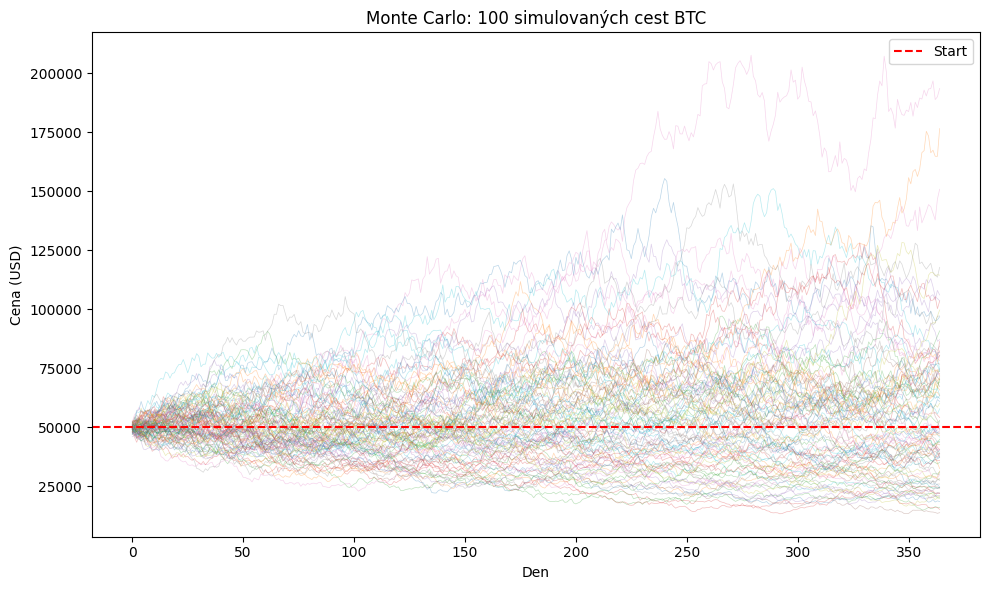

Medián konečné ceny: $49,142
5. percentil: $20,214
95. percentil: $106,542


In [121]:
# Monte Carlo simulace cen BTC

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

S0 = 50000      # pocatecni cena BTC
mu = 0.0005     # prumerny denni vynos 0.05 %
sigma = 0.03    # denni volatilita 3 %
pocet_dnu = 365
n_paths = 100   # pocet simulaci

random_returns = np.random.normal(mu, sigma, (pocet_dnu, n_paths))    # np.random.normal ma stale pouze tri argumenty, tj mean, std, size, akorat uz to neni 1D, ale 2D (365 radku, 100 sloupcu)

price_paths = S0 * np.cumprod(1 + random_returns, axis=0)

# vizualizace (copypastnul jsem)
plt.figure(figsize=(10, 6))
plt.plot(price_paths, alpha=0.3, linewidth=0.5)
plt.axhline(y=S0, color="red", linestyle="--", label="Start")
plt.title("Monte Carlo: 100 simulovaných cest BTC")
plt.xlabel("Den")
plt.ylabel("Cena (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("/home/kalinka/Kod/quant/notebooks/plots/F0/L3-monte_carlo_paths.png", dpi=150)
plt.show()
# statistiky koncovych cen
final_prices = price_paths[-1, :] # Poslední řádek = den 365
print(f"Medián konečné ceny: ${np.median(final_prices):,.0f}")
print(f"5. percentil: ${np.percentile(final_prices, 5):,.0f}")
print(f"95. percentil: ${np.percentile(final_prices, 95):,.0f}")